In [2]:
import os
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats
from matplotlib import pyplot as plt

import arfcexp.hcp
from arfcexp.skarf_utils import AVAILABLE_SKARF_FUNCS

In [3]:
pd.options.display.precision = 4

In [4]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /home/aerkent/skarf-experiments/resources/clane.mplstyle
3.42 png


In [5]:
project_root = Path(os.environ["PROJECT_ROOT"])

pred_perm_result_dir = (
    project_root / "results/hcp_1200_pyspi_behav_prediction_perm_test"
)
pred_baseline_result_dir = (
    project_root / "results/hcp_1200_pyspi_behav_prediction_all_targets_cov"
)
pred_full_result_dir = (
    project_root / "results/hcp_1200_skarf_behav_prediction_factor_full"
)

pred_analysis_dir = project_root / "results/hcp_1200_skarf_behav_prediction_analysis"
pred_analysis_dir.mkdir(exist_ok=True)

Load HCP behavioral columns.

In [6]:
hcp_behav_columns = list(arfcexp.hcp.load_hcp_behav_columns())
hcp_factor_targets = list(arfcexp.hcp.load_hcp_behav_factors_topk())

hcp_factor_order = np.load(
    project_root / "results/hcp_1200_behav/hcp_1200_behav_factor_order.npy"
)
hcp_factor_components = np.load(
    project_root / "results/hcp_1200_behav/hcp_1200_behav_factors.npy"
)

hcp_behav_column_factor_id = np.argmax(np.abs(hcp_factor_components), axis=0)

Misc shared utils.

In [7]:
metric_names = {
    "r2": "$R^2$",
    "corr": "Corr",
    "mse": "MSE",
}

In [8]:
def get_significance(pvalue: float) -> int:
    if pvalue < 0.001:
        return 3
    if pvalue < 0.01:
        return 2
    if pvalue < 0.05:
        return 1
    return 0

### Permutation null distribution

Load the permutation-based null distribution computed previously.

In [9]:
perm_result_paths = sorted(pred_perm_result_dir.rglob("results.json"))
print("Num perm test result files:", len(perm_result_paths))

perm_results = pd.concat([pd.read_json(path, lines=True) for path in perm_result_paths])

print("Perm test result table shape:", perm_results.shape)

Num perm test result files: 4
Perm test result table shape: (800, 18)


### Empirical covariance baseline on all targets

Load the empirical covariance baseline distribution computed previously.

In [10]:
baseline_result_paths = sorted(pred_baseline_result_dir.rglob("results.json"))
print("Num baseline test result files:", len(baseline_result_paths))

baseline_results = pd.concat(
    [pd.read_json(path, lines=True) for path in baseline_result_paths]
)

print("Baseline test result table shape:", baseline_results.shape)

Num baseline test result files: 59
Baseline test result table shape: (1180, 18)


### All skarf funcs on four factors

Compare all skarf funcs on the four factors.

Although we have four factors, we'll focus on just cognition since that is the most predictable factor.

- 2 lags x 12 funcs x 4 factors = 96 files
- 20 splits = 1920 rows 

In [11]:
full_result_paths = sorted(pred_full_result_dir.rglob("results.json"))
print("Num full test result files:", len(full_result_paths))

full_results = pd.concat([pd.read_json(path, lines=True) for path in full_result_paths])

full_results["func"] = pd.Categorical(
    full_results["func"], categories=AVAILABLE_SKARF_FUNCS, ordered=True
)

print("Full test result table shape:", full_results.shape)

Num full test result files: 96
Full test result table shape: (1920, 20)


In [12]:
full_results.head(5)

,func,target,parc_size,pool,lag,order,n_splits,perm_test,seed,split,n_train,n_test,alpha,r2_train,r2_val,r2_test,mse_train,mse_test,corr_train,corr_test
0,cov_empirical,Cognition,200,3,0,1,20,False,2142,0,697,170,0.7,0.5221,0.1221,0.1629,0.4779,0.6463,0.8142,0.4104
1,cov_empirical,Cognition,200,3,0,1,20,False,2142,1,700,167,0.7,0.5230,0.1206,0.1960,0.4770,0.9124,0.8193,0.4737
2,cov_empirical,Cognition,200,3,0,1,20,False,2142,2,702,165,0.4,0.6402,0.1741,0.1228,0.3598,0.8431,0.8719,0.4015
3,cov_empirical,Cognition,200,3,0,1,20,False,2142,3,701,166,0.7,0.5191,0.1293,0.2121,0.4809,0.7340,0.8170,0.4749
4,cov_empirical,Cognition,200,3,0,1,20,False,2142,4,711,156,0.4,0.6252,0.1255,0.2547,0.3748,0.8018,0.8649,0.5175


In [13]:
full_results_agg = full_results.groupby(["func", "target", "lag"], observed=True).agg(
    {"split": "count", "r2_test": "median", "corr_test": "median"}
)

full_results_agg.loc[pd.IndexSlice[:, "Cognition", 1], :]

,,,split,r2_test,corr_test
func,target,lag,,,
cov_empirical,Cognition,1,20,0.1530,0.4034
cov_graphicallasso,Cognition,1,20,0.1412,0.3913
prec_empirical,Cognition,1,20,-0.0076,-0.0056
prec_graphicallasso,Cognition,1,20,0.1083,0.3465
linear_ols,Cognition,1,20,-0.0062,0.0513
linear_ridge,Cognition,1,20,0.1786,0.4335
linear_lasso,Cognition,1,20,0.1344,0.3929
linear_enet,Cognition,1,20,0.1576,0.4046
linear_lasso-pos,Cognition,1,20,0.1253,0.3768


Test for significant prediction compared to empirical null distribution, and difference compared to baseline.

In [14]:
full_two_sample_comparisons = []

for func, target, lag, metric in itertools.product(
    AVAILABLE_SKARF_FUNCS,
    hcp_factor_targets,
    [0, 1],
    ["r2", "corr"],
):
    null_values = perm_results[f"{metric}_test"].values
    baseline_values = baseline_results.loc[
        baseline_results["target"] == target, f"{metric}_test"
    ].values

    values = full_results.query(
        f"func == '{func}' and target == '{target}' and lag == {lag}"
    )[f"{metric}_test"].values

    if len(values):
        null_stat, null_pval = scipy.stats.mannwhitneyu(
            values, null_values, alternative="greater"
        )
        baseline_stat, baseline_pval = scipy.stats.mannwhitneyu(values, baseline_values)

    else:
        null_stat = null_pval = baseline_stat = baseline_pval = np.nan

    full_two_sample_comparisons.append(
        {
            "func": func,
            "target": target,
            "lag": lag,
            "metric": metric,
            "reference": "null",
            "stat": null_stat,
            "pval": null_pval,
        }
    )
    full_two_sample_comparisons.append(
        {
            "func": func,
            "target": target,
            "lag": lag,
            "metric": metric,
            "reference": "baseline",
            "stat": baseline_stat,
            "pval": baseline_pval,
        }
    )

full_two_sample_comparisons = pd.DataFrame.from_records(full_two_sample_comparisons)
full_two_sample_comparisons = full_two_sample_comparisons.set_index(
    ["func", "target", "lag", "metric", "reference"]
)

In [15]:
full_two_sample_comparisons.loc[pd.IndexSlice[:, "Cognition", 1, "r2", "baseline"], :]

,,,,,stat,pval
func,target,lag,metric,reference,,
cov_empirical,Cognition,1,r2,baseline,150.0,1.8058e-01
cov_graphicallasso,Cognition,1,r2,baseline,132.0,6.7868e-02
prec_empirical,Cognition,1,r2,baseline,0.0,6.7956e-08
prec_graphicallasso,Cognition,1,r2,baseline,119.0,2.9441e-02
linear_ols,Cognition,1,r2,baseline,0.0,6.7956e-08
linear_ridge,Cognition,1,r2,baseline,230.0,4.2488e-01
linear_lasso,Cognition,1,r2,baseline,121.0,3.3718e-02
linear_enet,Cognition,1,r2,baseline,157.0,2.5030e-01
linear_lasso-pos,Cognition,1,r2,baseline,123.0,3.8515e-02


In [16]:
func_categories = {
    "cov": ["cov_empirical", "cov_graphicallasso"],
    "prec": ["prec_empirical", "prec_graphicallasso"],
    "lstsq": ["linear_ols", "linear_ridge"],
    "sparse": ["linear_lasso", "linear_enet"],
    "sparse-pos": ["linear_lasso-pos", "linear_enet-pos"],
    "lowrank": ["linear_pls", "linear_pca-ridge"],
}

func_category_map = {
    func: category for category, funcs in func_categories.items() for func in funcs
}

func_category_colors = {
    category: color_cycle[ii] for ii, category in enumerate(func_categories)
}

func_names = {
    "cov_empirical": "cov_empirical",
    "cov_graphicallasso": "cov_graphlasso",
    "prec_empirical": "prec_empirical",
    "prec_graphicallasso": "prec_graphlasso",
    "linear_ols": "lstsq_ols",
    "linear_ridge": "lstsq_ridge",
    "linear_lasso": "sparse_lasso",
    "linear_enet": "sparse_enet",
    "linear_lasso-pos": "sparse-pos_lasso",
    "linear_enet-pos": "sparse-pos_enet",
    "linear_pls": "lowrank_pls",
    "linear_pca-ridge": "lowrank_pca-ridge",
}

In [17]:
def plot_full_boxplots_funcs(
    target: str = "Cognition", lag: int = 0, metric: str = "r2"
):
    # correct for the number of SPI comparisons
    num_comparisons = len(AVAILABLE_SKARF_FUNCS)

    # empirical covariance baseline score
    baseline_score = baseline_results.loc[
        baseline_results["target"] == target, f"{metric}_test"
    ].median()

    data = []
    labels = []
    colors = []

    # Get top-k spis for each spi family
    for func in AVAILABLE_SKARF_FUNCS:
        values = full_results.query(
            f"func == '{func}' and target == '{target}' and lag == {lag}"
        )[f"{metric}_test"].values
        score = np.median(values)

        null_pval, baseline_pval = full_two_sample_comparisons.loc[
            (func, target, lag, metric, slice(None)), "pval"
        ]

        name = func_names[func]
        _, label = name.split("_", maxsplit=1)

        # (·): not significantly > null
        # (<): significantly < baseline
        # (~): not significantly different from baseline
        if not get_significance(null_pval * num_comparisons):
            label = f"(·) {label}"
        elif get_significance(baseline_pval * num_comparisons):
            label = f"({'<' if score < baseline_score else '>'}) {label}"
        else:
            label = f"(~) {label}"

        color = func_category_colors[func_category_map[func]]

        data.append(values)
        labels.append(label)
        colors.append(color)

    f, ax = plt.subplots(
        1, 1, figsize=(1.0 * PLOTW, 0.75 * PLOTW), layout="constrained"
    )

    pos = np.arange(len(data))
    bplot = plt.boxplot(
        data,
        positions=pos,
        patch_artist=True,
        medianprops={"color": "k"},  # , flierprops={"clip_on": False}
    )

    # fill with colors
    for patch, color in zip(bplot["boxes"], colors):
        patch.set_facecolor(color)

    plt.ylabel(metric_names[metric], fontsize="medium")
    plt.xticks(pos, labels, rotation=90, fontsize="x-small")
    plt.axhline(baseline_score, color="r", alpha=0.5)

    ymin, ymax = plt.ylim()
    ymax = ymin + 1.1 * (ymax - ymin)
    plt.ylim(ymin, ymax)

    # dummy bars for legend
    for category, color in func_category_colors.items():
        plt.bar([0], [0], width=0, color=color, edgecolor="none", label=category)
    plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize="small")

    return f

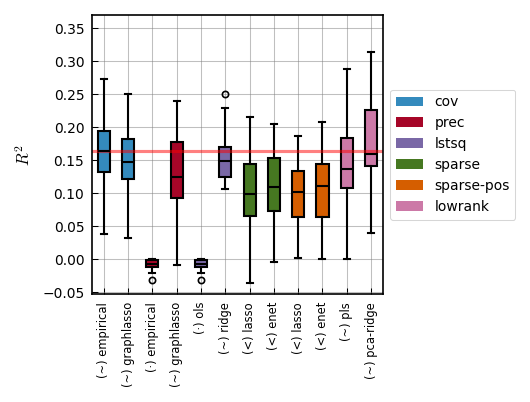

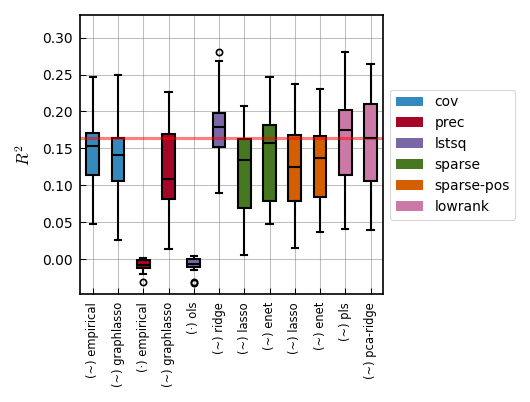

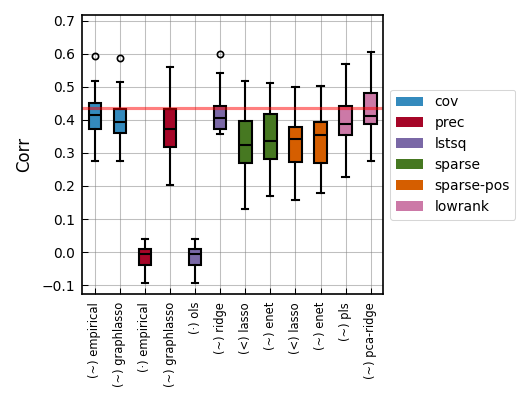

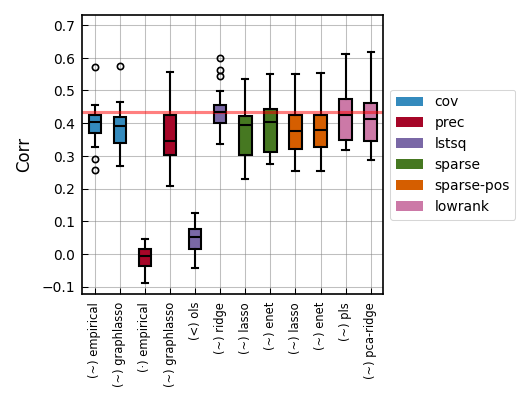

In [18]:
target = "Cognition"

for metric, lag in itertools.product(["r2", "corr"], [0, 1]):
    f = plot_full_boxplots_funcs(target=target, lag=lag, metric=metric)
    f.savefig(
        pred_analysis_dir
        / f"full_prediction_boxplots_lag-{lag}_{target}_{metric}.{FORMAT}",
        bbox_inches="tight",
    )

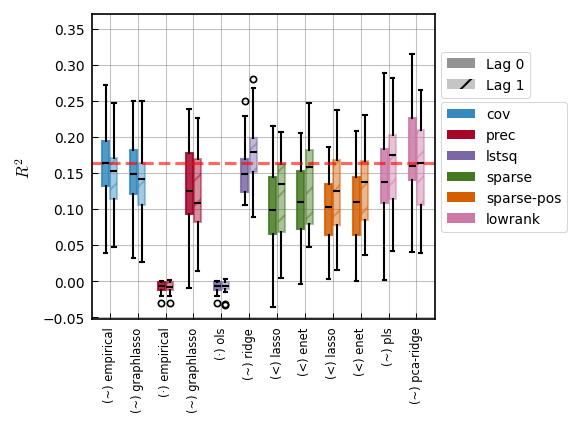

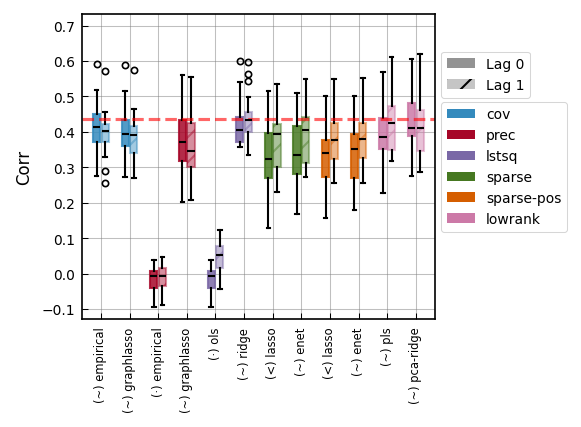

In [20]:
import matplotlib.patches as mpatches

target = "Cognition"
lags = [0, 1]
lag_styles = {0: {"alpha": 0.85, "hatch": ""}, 1: {"alpha": 0.45, "hatch": "//"}}
metric_list = ["r2", "corr"]

num_comparisons = len(AVAILABLE_SKARF_FUNCS)
positions = np.arange(len(AVAILABLE_SKARF_FUNCS))

for metric in metric_list:
    metric_col = f"{metric}_test"
    baseline_score = baseline_results.loc[baseline_results["target"] == target, metric_col].median()

    labels = []
    category_colors = []
    for func in AVAILABLE_SKARF_FUNCS:
        null_pval, baseline_pval = full_two_sample_comparisons.loc[(func, target, 0, metric, slice(None)), "pval"]

        name = func_names[func]
        _, label = name.split("_", maxsplit=1)

        if not get_significance(null_pval * num_comparisons):
            label = f"(·) {label}"
        elif get_significance(baseline_pval * num_comparisons):
            lag0_values = full_results.query("func == @func and target == @target and lag == 0")[metric_col].values
            label = f"({'<' if np.median(lag0_values) < baseline_score else '>'}) {label}"
        else:
            label = f"(~) {label}"

        labels.append(label)
        category_colors.append(func_category_colors[func_category_map[func]])

    fig, ax = plt.subplots(1, 1, figsize=(1.1 * PLOTW, 0.8 * PLOTW), layout="constrained")

    for offset, lag in zip(np.linspace(-0.15, 0.15, len(lags)), lags):
        lag_data = [
            full_results.query("func == @func and target == @target and lag == @lag")[metric_col].values
            for func in AVAILABLE_SKARF_FUNCS
        ]

        bplot = ax.boxplot(
            lag_data,
            positions=positions + offset,
            widths=0.25,
            patch_artist=True,
            medianprops={"color": "k"},
        )

        for patch, color in zip(bplot["boxes"], category_colors):
            patch.set_facecolor(color)
            patch.set_alpha(lag_styles[lag]["alpha"])
            patch.set_hatch(lag_styles[lag]["hatch"])
            patch.set_edgecolor(color)

    ax.set_ylabel(metric_names[metric], fontsize="medium")
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=90, fontsize="x-small")
    ax.axhline(baseline_score, color="r", alpha=0.6, linestyle="--")

    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymin + 1.1 * (ymax - ymin))

    lag_handles = [
        mpatches.Patch(
            facecolor="gray",
            alpha=lag_styles[lag]["alpha"],
            hatch=lag_styles[lag]["hatch"],
            label=f"Lag {lag}",
        )
        for lag in lags
    ]
    lag_legend = ax.legend(
        handles=lag_handles,
        # title="Lag",
        loc="upper left",
        bbox_to_anchor=(1.0, 0.9),
        fontsize="small",
    )
    ax.add_artist(lag_legend)

    category_handles = [
        mpatches.Patch(facecolor=color, label=category)
        for category, color in func_category_colors.items()
    ]
    ax.legend(
        handles=category_handles,
        # title="Function family",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize="small",
    )

    fig.savefig(
        pred_analysis_dir
        / f"full_prediction_boxplots_lag-combined_{target}_{metric}.{FORMAT}",
        bbox_inches="tight",
    )
    plt.show()